# 10 — Continuous Healing Index

**Stage 9 · turns the binary classifier into a graded, reusable score**

Convert the Stage 8 binary TSPC/T-FAP classifier into a continuous **Healing Index**: a
per-cell score where high = regenerative (TSPC-like) and low = fibrotic (T-FAP-like),
usable on whole populations rather than just a hard TSPC/T-FAP call, and reusable on
future lab datasets.

- **Model:** `classifier_core_23.joblib` (Stage 8 primary — 23-gene unanimous panel, better cross-dataset generalisation than the 44-gene panel)
- **Score construction:** raw log-odds (`decision_function`) rather than the sigmoid probability — see §2 for why — percentile-calibrated against the Harvey 2019 training population so the 0–100 scale has a fixed, documented reference and stays comparable across datasets
- **Applied to:** Harvey 2019 (self-reference sanity check) and Cherief 2023 (the actual out-of-dataset application, already validated in Stage 8)
- **Cross-checked against:** CellRank TSPC fate probabilities (Stage 4), an independent trajectory-based estimate computed by a completely different method
- **"New lab dataset" requirement:** no third tendon scRNA-seq dataset exists in this repository yet. §6 provides a documented, turnkey scoring function for when one arrives, rather than fabricating a demonstration on data that doesn't exist.

**Inputs**
- `data/classifier/classifier_core_23.joblib` — from `09`
- `data/Harvey_scRNA-seq/harvey2019_processed.h5ad` — from `03`, the calibration reference population
- `data/Cherief_scRNA-seq/GSE244921_cluster8_sub.h5ad` — from `02`
- `data/Cherief_scRNA-seq/GSE244921_cluster8_cellrank.h5ad` — from `05`, for the independent cross-check

**Outputs**
- `data/healing_index/harvey_reference_scores.npy` — the fixed percentile-calibration reference
- `data/healing_index/cherief_healing_index.csv` — per-cell Healing Index, all 3,900 cluster-8 cells
- `figures/healing_index/` — score distributions, CellRank cross-check scatter

**Runs after:** `09` · **Feeds:** — (end of the Stage 0–9 pipeline)

**Environment:** analysis env (`environments/analysis.txt`). Run with the working directory set to `scripts/ipynb/` — every path below is relative to it.


## 0. Setup

Imports, paths and output directories.


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import spearmanr

ROOT = Path('../..')
DATA_HV = ROOT / 'data' / 'Harvey_scRNA-seq'
DATA_CH = ROOT / 'data' / 'Cherief_scRNA-seq'
DATA_CLF = ROOT / 'data' / 'classifier'
OUT_DATA = ROOT / 'data' / 'healing_index'
OUT_FIG = ROOT / 'figures' / 'healing_index'
OUT_DATA.mkdir(exist_ok=True)
OUT_FIG.mkdir(exist_ok=True)

model_bundle = joblib.load(DATA_CLF / 'classifier_core_23.joblib')
genes = model_bundle['genes']
print(f'Loaded core_23 classifier: {len(genes)} genes')

Loaded core_23 classifier: 23 genes


## 1. Load helper for scoring any h5ad with this panel

Same pattern as Stages 7–8: use `.raw` (log1p-normalised, non-negative) and require all panel genes to be present.

In [2]:
def load_expression(path, genes):
    ad = sc.read_h5ad(path)
    ad = ad.raw.to_adata()
    missing = [g for g in genes if g not in ad.var_names]
    if missing:
        raise ValueError(f'{len(missing)} panel genes missing from {path.name}: {missing}')
    sub = ad[:, genes].copy()
    Xm = sub.X.toarray() if hasattr(sub.X, 'toarray') else np.asarray(sub.X)
    Xdf = pd.DataFrame(Xm, columns=genes, index=sub.obs_names)
    return Xdf, sub.obs

X_harvey, obs_harvey = load_expression(DATA_HV / 'harvey2019_processed.h5ad', genes)
X_cherief, obs_cherief = load_expression(DATA_CH / 'GSE244921_cluster8_sub.h5ad', genes)
print(f'Harvey: {X_harvey.shape[0]} cells, Cherief: {X_cherief.shape[0]} cells')

Harvey: 4069 cells, Cherief: 3900 cells


## 2. Score construction: log-odds, not raw probability

The Stage 8 violin plot showed the sigmoid probability is heavily saturated — 65% of Cherief cluster-8 cells sit at P(T-FAP) < 0.05 or > 0.95 — because the classifier was trained on two well-separated populations and is confident almost everywhere, including for cell types it never saw in training (Stromal, Tenogenic-progenitor). A saturated [0,1] probability compresses most of the population onto two points and loses resolution exactly where a continuous index is most useful: distinguishing degrees of fibrotic drift.

The **decision function** (pre-sigmoid log-odds of T-FAP) has far more dynamic range (Harvey-trained model, evaluated on Cherief: std ≈ 4.6, range ≈ −8.4 to 19.3) and preserves relative ordering without an artificial ceiling. Healing Index is built on `-decision_function` (positive = more TSPC-like = more regenerative), then percentile-calibrated against Harvey (the training population) so scores have a fixed, interpretable 0–100 reference scale rather than being re-normalised per dataset (which would make scores incomparable across studies).

In [3]:
def raw_score(X):
    Xs = model_bundle['scaler'].transform(X)
    return -model_bundle['clf'].decision_function(Xs)  # positive = more TSPC-like

reference_scores = raw_score(X_harvey)
reference_sorted = np.sort(reference_scores)
np.save(OUT_DATA / 'harvey_reference_scores.npy', reference_sorted)

def healing_index(X):
    scores = raw_score(X)
    percentile = np.searchsorted(reference_sorted, scores, side='left') / len(reference_sorted) * 100
    return np.clip(percentile, 0, 100)

print(f'Harvey reference distribution: n={len(reference_sorted)}, '
      f'raw score range [{reference_sorted.min():.2f}, {reference_sorted.max():.2f}]')

Harvey reference distribution: n=4069, raw score range [-18.10, 11.99]


## 3. Sanity check — score Harvey against its own reference

By construction this should span close to 0–100 with TSPC near 100 and T-FAP near 0; this is a check that the percentile machinery works correctly, not new information about generalisation (that's Stage 8's job).

In [4]:
harvey_hi = healing_index(X_harvey)
harvey_summary = pd.DataFrame({'healing_index': harvey_hi, 'cell_type': obs_harvey['cell_type'].values})
harvey_summary.groupby('cell_type')['healing_index'].describe()[['mean', '50%', 'std', 'min', 'max']]

C:\Users\fangy\AppData\Local\Temp\ipykernel_11484\3362026677.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  harvey_summary.groupby('cell_type')['healing_index'].describe()[['mean', '50%', 'std', 'min', 'max']]


,mean,50%,std,min,max
cell_type,,,,,
Endothelial,66.546168,70.324404,19.734406,6.045711,99.090686
Macrophage,61.026901,61.071516,21.392097,16.441386,98.795773
Nerve,57.149772,56.107152,16.738681,22.093881,89.211108
Smooth muscle,49.221769,46.424183,22.291308,3.145736,99.385598
T-FAP,9.081451,6.684689,8.716910,0.000000,72.327353
TSPC,81.232203,87.097567,17.628871,12.042271,99.975424
Tenocyte,57.693344,57.704596,23.776554,5.210125,99.901696
Unknown,41.340534,33.988695,27.938931,0.147456,99.754239


## 4. Apply to Cherief 2023

Score every cluster-8 cell (all four sub-populations), same population Stage 4's CellRank fate probabilities and Stage 8's distributional shift check used.

In [5]:
cherief_hi = healing_index(X_cherief)
cond_label_map = {'TrkAWT': 'Innervated', 'TrkAF592A': 'Denervated'}
cherief_summary = pd.DataFrame({
    'healing_index': cherief_hi,
    'cell_type': obs_cherief['cell_type'].values,
    'condition': obs_cherief['condition'].map(cond_label_map).values,
}, index=obs_cherief.index)
cherief_summary.to_csv(OUT_DATA / 'cherief_healing_index.csv')

print('By condition:')
print(cherief_summary.groupby('condition')['healing_index'].agg(['mean', 'median', 'std']))
print()
print('By cell type:')
print(cherief_summary.groupby('cell_type')['healing_index'].agg(['mean', 'median', 'std']))

By condition:
                 mean     median        std
condition                                  
Denervated  15.542836  12.435488  13.989861
Innervated  25.207459  18.948145  21.112830

By cell type:
                           mean     median        std
cell_type                                            
Stromal               22.288701  18.518063  15.664811
T-FAP                  7.359870   5.554190   7.482238
TSPC                  52.026708  51.167363  20.676867
Tenogenic-progenitor  21.189927  18.677808  11.434835


C:\Users\fangy\AppData\Local\Temp\ipykernel_11484\342340306.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(cherief_summary.groupby('condition')['healing_index'].agg(['mean', 'median', 'std']))
C:\Users\fangy\AppData\Local\Temp\ipykernel_11484\342340306.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(cherief_summary.groupby('cell_type')['healing_index'].agg(['mean', 'median', 'std']))


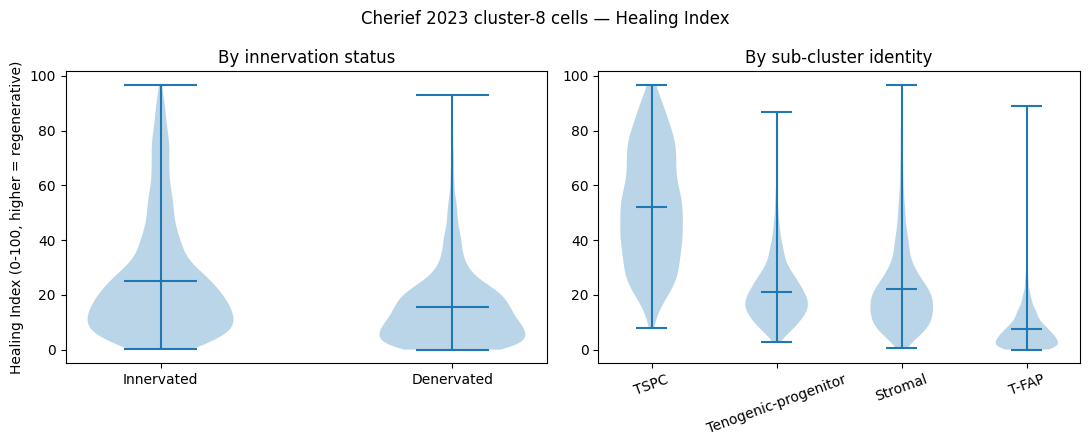

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

data = [cherief_summary.loc[cherief_summary['condition'] == c, 'healing_index'].values
        for c in ['Innervated', 'Denervated']]
axes[0].violinplot(data, showmeans=True)
axes[0].set_xticks([1, 2]); axes[0].set_xticklabels(['Innervated', 'Denervated'])
axes[0].set_ylabel('Healing Index (0-100, higher = regenerative)')
axes[0].set_title('By innervation status')

ct_order = ['TSPC', 'Tenogenic-progenitor', 'Stromal', 'T-FAP']
data_ct = [cherief_summary.loc[cherief_summary['cell_type'] == c, 'healing_index'].values for c in ct_order]
axes[1].violinplot(data_ct, showmeans=True)
axes[1].set_xticks(range(1, len(ct_order) + 1)); axes[1].set_xticklabels(ct_order, rotation=20)
axes[1].set_title('By sub-cluster identity')

fig.suptitle('Cherief 2023 cluster-8 cells — Healing Index')
fig.tight_layout()
fig.savefig(OUT_FIG / 'healing_index_cherief.png', dpi=150)
plt.show()

## 5. Cross-check against CellRank TSPC fate probability

`data/Cherief_scRNA-seq/GSE244921_cluster8_cellrank.h5ad` (Stage 4) carries CellRank terminal-state fate probabilities for the same 3,900 cells, computed by an unrelated method (diffusion-pseudotime kernel + GPCCA), not the ML classifier. Agreement between the two is a genuine independent cross-check; disagreement would be a red flag for the Healing Index. Recall the standing caveat from Stage 4: DPT pseudotime ordering itself was flagged as unreliable, so treat this as a directional sanity check, not proof either score is "ground truth."<br>Terminal-state columns are `['T-FAP_1', 'T-FAP_2', 'TSPC']` (alphabetical, confirmed against `term_states_fwd` categories and against the fact that TSPC-labelled cells average 99.95% TSPC fate probability in this column).

Spearman correlation, Healing Index vs. CellRank TSPC fate probability: rho=0.656, p=0.00e+00


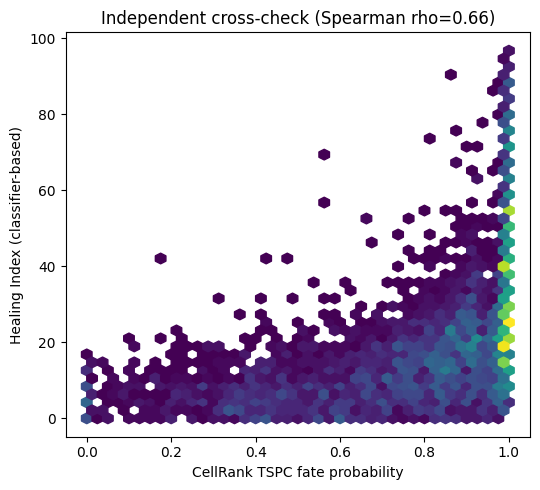

In [7]:
ad_cr = sc.read_h5ad(DATA_CH / 'GSE244921_cluster8_cellrank.h5ad')
lineages = np.asarray(ad_cr.obsm['lineages_fwd'])
tspc_fate_prob = pd.Series(lineages[:, 2], index=ad_cr.obs_names, name='cellrank_tspc_fate_prob')

merged = cherief_summary.join(tspc_fate_prob)
rho, pval = spearmanr(merged['healing_index'], merged['cellrank_tspc_fate_prob'])
print(f'Spearman correlation, Healing Index vs. CellRank TSPC fate probability: rho={rho:.3f}, p={pval:.2e}')

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.hexbin(merged['cellrank_tspc_fate_prob'], merged['healing_index'], gridsize=40, cmap='viridis', mincnt=1)
ax.set_xlabel('CellRank TSPC fate probability')
ax.set_ylabel('Healing Index (classifier-based)')
ax.set_title(f'Independent cross-check (Spearman rho={rho:.2f})')
fig.tight_layout()
fig.savefig(OUT_FIG / 'healing_index_vs_cellrank.png', dpi=150)
plt.show()

## 6. Turnkey scoring function for new lab datasets

No third tendon scRNA-seq dataset exists in this repository at the time of writing, so this section is not demonstrated against real new data — that would mean fabricating a result. What's provided instead is the exact function to run once one exists: point it at any `.h5ad` with the same preprocessing convention (raw counts normalised, log1p-transformed, stored in `.raw`, mouse gene symbols in `.var_names`) and it returns per-cell Healing Index scores calibrated against the same fixed Harvey 2019 reference used above, so scores stay comparable to everything computed in this notebook.

In [8]:
def score_new_dataset(h5ad_path, output_csv=None):
    """Score a new tendon scRNA-seq dataset with the Stage 8 core_23 classifier.

    Requires `.raw` to hold log1p-normalised expression with the 23 panel genes
    present in `.var_names` (mouse gene symbols). Returns a DataFrame indexed by
    cell barcode with columns `healing_index` (0-100, calibrated against the
    Harvey 2019 reference distribution) and `raw_score` (uncalibrated log-odds).
    """
    X_new, obs_new = load_expression(Path(h5ad_path), genes)
    scores = raw_score(X_new)
    result = pd.DataFrame({
        'raw_score': scores,
        'healing_index': healing_index(X_new),
    }, index=obs_new.index)
    if output_csv is not None:
        result.to_csv(output_csv)
    return result

print('score_new_dataset() defined — ready to run once a new lab dataset is available.')
print('Reference distribution saved at data/healing_index/harvey_reference_scores.npy')
print('Required panel genes (23):', ', '.join(genes))

score_new_dataset() defined — ready to run once a new lab dataset is available.
Reference distribution saved at data/healing_index/harvey_reference_scores.npy
Required panel genes (23): C3, Camk2n1, Cpxm1, Fth1, Igfbp7, Nfib, Ptx3, Rps29, Scn7a, Serping1, Slc38a2, Slfn5, Steap4, Zfp36l1, Aebp1, C1ra, Cebpd, Cxcl12, Lpl, Sema3c, Sfrp2, Tppp3, Zfp36


## 7. Summary

**Healing Index by condition (Cherief 2023, all 3,900 cluster-8 cells):** Innervated mean 25.2 (median 18.9) vs. Denervated mean 15.5 (median 12.4) — correct direction, denervation shifts the population toward the fibrotic end, consistent with every prior stage (LIANA signal loss, CellRank fate-probability shift, Stage 8's raw-probability shift check). The percentile transform gives this comparison much more visible structure than the Stage 8 probability version: both distributions now span close to the full 0–100 range instead of piling up at the extremes.

**By sub-cluster identity:** TSPC highest (mean 52.0), T-FAP lowest (mean 7.4), Stromal (22.3) and Tenogenic-progenitor (21.2) sit in between — a sensible ordering given neither of the latter two was in the training data, and both were described in Stage 1c as adjacent-but-distinct progenitor-like states rather than committed T-FAP.

**Independent cross-check against CellRank:** Spearman rho = 0.656 (p ≈ 0) between the Healing Index and CellRank's TSPC terminal-state fate probability — a moderately strong positive correlation from two methods that share no code path (logistic regression on 23 genes vs. a diffusion-pseudotime kernel + GPCCA over the whole transcriptome). Not a perfect correlation, and it shouldn't be: CellRank's own DPT-based ordering was flagged in Stage 4 as unreliable, visible here too as a dense vertical band of cells sitting at CellRank fate probability ≈ 1.0 across a wide range of Healing Index values. Read the agreement as directional corroboration from an independent method, not as validating either score against a ground truth neither has.

**Deliverables:** `data/healing_index/harvey_reference_scores.npy` (the fixed calibration reference — needed for any future scoring to stay on a comparable scale), `data/healing_index/cherief_healing_index.csv` (per-cell scores), and `score_new_dataset()` (Section 6) — a documented one-call function for scoring a new lab dataset the moment one exists, using the same reference and the same 23-gene panel.

**This closes the Stage 0–9 pipeline as originally scoped in `docs/progress.md`.** What isn't done, and is worth being explicit about rather than letting the clean numbers imply otherwise: this whole pipeline rests on two datasets that between them have zero biological replicates, so every "validation" performed (Harvey CV, Cherief generalisation, the CellRank cross-check) is a within- or cross-*dataset* check, not a cross-*animal* or cross-*cohort* one. The natural next step, beyond original scope, is applying `score_new_dataset()` to new lab-generated tendon scRNA-seq once available — that would be the first real biological-replicate test this signature has faced.